In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('../data/retail_data.csv')

In [3]:
df.shape

(1067371, 9)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Unnamed: 0   1067371 non-null  int64  
 1   Invoice      1067371 non-null  str    
 2   StockCode    1067371 non-null  str    
 3   Description  1062989 non-null  str    
 4   Quantity     1067371 non-null  int64  
 5   InvoiceDate  1067371 non-null  str    
 6   Price        1067371 non-null  float64
 7   Customer ID  824364 non-null   float64
 8   Country      1067371 non-null  str    
dtypes: float64(2), int64(2), str(5)
memory usage: 73.3 MB


In [5]:
df.head()

,Unnamed: 0,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
df.describe()

,Unnamed: 0,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,1.067371e+06,824364.000000
mean,2.669056e+05,9.938898e+00,4.649388e+00,15324.638504
std,1.541715e+05,1.727058e+02,1.235531e+02,1697.464450
min,0.000000e+00,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.334210e+05,1.000000e+00,1.250000e+00,13975.000000
50%,2.668420e+05,3.000000e+00,2.100000e+00,15255.000000
75%,4.002635e+05,1.000000e+01,4.150000e+00,16797.000000
max,5.419090e+05,8.099500e+04,3.897000e+04,18287.000000


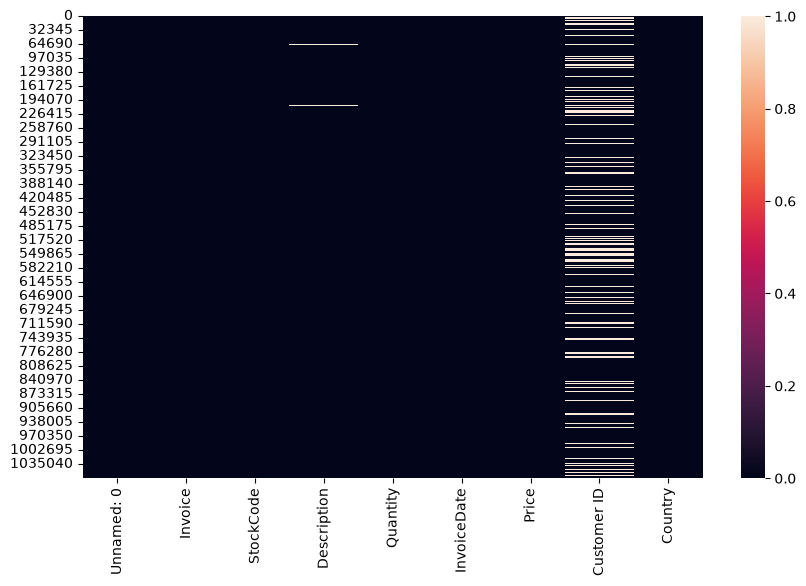

In [7]:
# Seeing the missing values
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull())
plt.show()

In [10]:
df.isnull().sum()

Unnamed: 0          0
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [9]:
df=df.drop_duplicates()

In [17]:
df.isnull().sum()

Unnamed: 0          0
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [ ]:
df=df.drop_duplicates()

In [ ]:
df['Invoice'].unique()

<StringArray>
['489434', '489435', '489436', '489437', '489438', '489439', '489440',
 '489441', '489442', '489443',
 ...
 '581578', '581579', '581581', '581580', '581582', '581583', '581584',
 '581585', '581586', '581587']
Length: 53628, dtype: str

# extract year and month columns from the invoice date

In [19]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])

In [20]:
df['InvoiceDate'].dtype

dtype('<M8[us]')

In [21]:
df['Month']=df['InvoiceDate'].dt.month

In [22]:
df['Year']=df['InvoiceDate'].dt.year

In [23]:
df['Year'].value_counts()

Year
2010    522714
2011    499429
2009     45228
Name: count, dtype: int64

In [24]:
df['StockCode'].nunique()

5305

# Creating the Sales Column

In [26]:
# creating total_ sales column
df['Sales']=df['Price']*df['Quantity']

In [27]:
sales_df = df[(df['Quantity']>0) & (df['Price']>0) & df['Customer ID'].notna()]

In [28]:
return_df = df[(df['Quantity']<0) & df['Customer ID'].isna()]

In [29]:
sales_df.head(3)

,Unnamed: 0,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Month,Year,Sales
0,0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,12,2009,83.4
1,1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,12,2009,81.0
2,2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,12,2009,81.0


In [30]:
sales_df.shape


(805549, 12)

In [31]:
sales_df.isnull().sum()

Unnamed: 0     0
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
Month          0
Year           0
Sales          0
dtype: int64

In [33]:
return_df.head()

,Unnamed: 0,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Month,Year,Sales
263,263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom,12,2009,-0.0
283,283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom,12,2009,-0.0
284,284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom,12,2009,-0.0
470,470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom,12,2009,-0.0
3114,3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom,12,2009,-0.0


In [34]:
return_df.shape

(4206, 12)

In [35]:
df.to_csv("../data/sales_df.csv")

In [36]:
import os
path="../data/sales_df.csv"
print(f"{os.path.getsize(path) / (1024**2):.2f} MB")

120.35 MB
